In [ ]:
!pip uninstall -y pillow pil
!pip install --upgrade pip setuptools wheel
!pip install pillow==10.0.0
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install scenedetect[opencv]
!pip install scikit-learn matplotlib imageio tqdm opencv-python
!pip install ftfy regex
!git clone https://github.com/openai/CLIP.git
%cd CLIP
!pip install .
%cd ..

print("Installation complete! Testing imports...")

# Test imports
try:
    from PIL import Image
    import clip
    print("✓ All imports successful!")
    print("Pillow version:", Image.__version__)
except Exception as e:
    print(f"✗ Error: {e}")

Found existing installation: Pillow 10.0.0
Uninstalling Pillow-10.0.0:
  Successfully uninstalled Pillow-10.0.0
  Using cached Pillow-10.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.5 kB)
Using cached Pillow-10.0.0-cp312-cp312-manylinux_2_28_x86_64.whl (3.4 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 10.0.0 which is incompatible.
Looking in indexes: https://download.pytorch.org/whl/cu118
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scenedetect]
Cloning into 'CLIP'...
remote: Enumerating objects: 256, done.
remote: Total 256 (delta 0), reused 0 (delta 0), pack-reused 256 (from 1)
Receiving objects: 100% (256/256), 8.93 MiB | 19.70 MiB

In [ ]:
#Cell 2

# Imports and basic setup
import os, math, time, csv
from pathlib import Path
from typing import List, Tuple, Dict

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from scenedetect import VideoManager, SceneManager
from scenedetect.detectors import ContentDetector
import torch, clip

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"

# Output folders
BASE = Path.cwd() / "lmske_output"
FRAMES_DIR = BASE / "frames"
KEYFRAMES_DIR = BASE / "keyframes"
for d in [BASE, FRAMES_DIR, KEYFRAMES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def timestamp_from_frame(frame_idx:int, fps:float)->str:
    secs = frame_idx / max(1.0, fps)
    return time.strftime("%H:%M:%S", time.gmtime(secs)) + f".{int((secs%1)*1000):03d}"

print("Setup done. Output base:", BASE)

/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


torch version: 2.9.0+cu126
CUDA available: False
Setup done. Output base: /content/lmske_output


In [ ]:
#Cell 3

VIDEO_PATH = "/content/vid.mp4"

assert os.path.exists(VIDEO_PATH), f"Video not found at {VIDEO_PATH}. Upload the file or change the path."

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / max(1.0, fps)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"Video: {VIDEO_PATH}")
print(f"FPS: {fps:.2f}, Frames: {frame_count}, Duration: {duration:.2f}s, Size: {width}x{height}")

Video: /content/vid.mp4
FPS: 25.00, Frames: 29219, Duration: 1168.76s, Size: 1280x720


In [ ]:
#Cell 4

def detect_scenes_pyscenedetect(VIDEO_PATH: str, threshold: float = 27.0) -> List[Tuple[int, int]]:
    """
    Return list of (start_frame, end_frame) for each detected shot.
    threshold: sensitivity (lower -> more cuts; higher -> fewer cuts).
    """
    vm = VideoManager([VIDEO_PATH])
    sm = SceneManager()
    sm.add_detector(ContentDetector(threshold=threshold))
    vm.start()
    sm.detect_scenes(frame_source=vm)
    scene_list = sm.get_scene_list()
    vm.release()

    shots = []
    for s in scene_list:
        start = int(s[0].get_frames())
        end = int(s[1].get_frames()) - 1
        shots.append((start, max(start, end)))
    return shots

# Run shot detection
SCENE_THRESHOLD = 27.0
shots = detect_scenes_pyscenedetect(VIDEO_PATH, threshold=SCENE_THRESHOLD)
print(f"Detected {len(shots)} shots.")
for i,(s,e) in enumerate(shots[:10]):
    print(f"Shot {i:02d}: frames {s}–{e} ({timestamp_from_frame(s, fps)} to {timestamp_from_frame(e, fps)})")

ERROR:pyscenedetect:VideoManager is deprecated and will be removed.
INFO:pyscenedetect:Loaded 1 video, framerate: 25.000 FPS, resolution: 1280 x 720
INFO:pyscenedetect:Detecting scenes...


Detected 11 shots.
Shot 00: frames 0–125 (00:00:00.000 to 00:00:05.000)
Shot 01: frames 126–404 (00:00:05.040 to 00:00:16.160)
Shot 02: frames 405–443 (00:00:16.199 to 00:00:17.719)
Shot 03: frames 444–664 (00:00:17.760 to 00:00:26.559)
Shot 04: frames 665–765 (00:00:26.600 to 00:00:30.600)
Shot 05: frames 766–845 (00:00:30.640 to 00:00:33.799)
Shot 06: frames 846–25201 (00:00:33.840 to 00:16:48.039)
Shot 07: frames 25202–28497 (00:16:48.080 to 00:18:59.880)
Shot 08: frames 28498–28809 (00:18:59.920 to 00:19:12.359)
Shot 09: frames 28810–29214 (00:19:12.400 to 00:19:28.559)


In [ ]:
# Cell 5

# Sampling and CLIP loader
SAMPLE_EVERY = 10  # sample 1 frame every N frames
BATCH_SIZE = 64    # batch size for CLIP encoding

print("Loading CLIP model (ViT-B/32) on device:", device)
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

def extract_sampled_frames(VIDEO_PATH: str, start_f: int, end_f: int, every:int=10):
    """
    Sample frames between start_f and end_f inclusive, every N frames.
    Returns two lists: sampled frame indices (absolute in video) and PIL images (RGB).
    """
    cap = cv2.VideoCapture(VIDEO_PATH)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_f)
    fr_indices = []
    images = []
    i = start_f
    total = max(0, end_f - start_f + 1)
    pbar = tqdm(total=total, desc=f"Sampling frames {start_f}-{end_f}")
    while i <= end_f:
        ret, frame = cap.read()
        if not ret:
            break
        if (i - start_f) % every == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            images.append(Image.fromarray(rgb))
            fr_indices.append(i)
        i += 1
        pbar.update(1)
    pbar.close()
    cap.release()
    return fr_indices, images

@torch.no_grad()
def clip_encode_images(pil_images: List[Image.Image], batch_size:int=64) -> np.ndarray:
    """
    Encode a list of PIL images with CLIP, return numpy array [N, D].
    """
    if len(pil_images) == 0:
        return np.zeros((0, clip_model.visual.output_dim if hasattr(clip_model.visual, 'output_dim') else 512), dtype=np.float32)
    feats = []
    for i in range(0, len(pil_images), batch_size):
        batch = pil_images[i:i+batch_size]
        batch_t = torch.stack([clip_preprocess(img) for img in batch]).to(device)
        with torch.no_grad():
            out = clip_model.encode_image(batch_t)
            out = out / out.norm(dim=-1, keepdim=True)
            feats.append(out.cpu().numpy().astype(np.float32))
    if feats:
        return np.vstack(feats)
    else:
        return np.zeros((0,512), dtype=np.float32)

# Sanity check on first shot
if len(shots) == 0:
    raise RuntimeError("No shots found. Try lowering SCENE_THRESHOLD.")

start_f, end_f = shots[0]
idxs, imgs = extract_sampled_frames(VIDEO_PATH, start_f, end_f, every=SAMPLE_EVERY)
feats = clip_encode_images(imgs, batch_size=BATCH_SIZE)
print("Sampled frames:", len(idxs), "Feature matrix shape:", feats.shape)

Loading CLIP model (ViT-B/32) on device: cpu


100%|███████████████████████████████████████| 338M/338M [00:07<00:00, 48.5MiB/s]
Sampling frames 0-125: 100%|██████████| 126/126 [00:00<00:00, 335.27it/s]


Sampled frames: 13 Feature matrix shape: (13, 512)


In [ ]:
#cell6
def choose_best_k(features: np.ndarray, kmax: int) -> int:
    """
    Choose best K using silhouette score over k=2..kmax.
    If features are few, returns 1.
    """
    n = len(features)
    if n <= 1:
        return 1
    X = normalize(features)  # normalize before clustering
    best_k, best_score = 1, -1.0
    # ensure kmax at least 2 if possible
    for k in range(2, min(max(2, kmax), n) + 1):
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
        labels = kmeans.fit_predict(X)
        if len(set(labels)) < 2:
            continue
        score = silhouette_score(X, labels)
        if score > best_score:
            best_k, best_score = k, score
    return best_k

def candidate_keyframes_per_shot(frame_idxs: List[int], features: np.ndarray) -> List[int]:
    """
    Given sampled frame indices and their features for a single shot,
    return a list of candidate keyframe frame indices (absolute indices).
    """
    if len(frame_idxs) == 0:
        return []
    if len(frame_idxs) <= 3:
        # Not enough samples: pick the middle frame
        return [frame_idxs[len(frame_idxs)//2]]
    kmax = max(1, int(math.sqrt(len(frame_idxs))))
    best_k = choose_best_k(features, kmax)
    X = normalize(features)
    kmeans = KMeans(n_clusters=max(1,best_k), n_init=10, random_state=0).fit(X)
    centers = kmeans.cluster_centers_
    labels = kmeans.labels_
    cand_idxs = []
    for c in range(len(centers)):
        members = np.where(labels == c)[0]
        if len(members) == 0:
            continue
        sub = X[members]
        dists = np.linalg.norm(sub - centers[c], axis=1)
        best_member = members[np.argmin(dists)]
        cand_idxs.append(frame_idxs[best_member])
    cand_idxs = sorted(set(cand_idxs))
    return cand_idxs

# Quick test for first shot
cand = candidate_keyframes_per_shot(idxs, feats)
print("Candidate keyframes (first shot):", cand, "count:", len(cand))

Candidate keyframes (first shot): [10, 120] count: 2


In [ ]:
#cell7
def read_frames(VIDEO_PATH: str, frame_indices: List[int]) -> List[np.ndarray]:
    """
    Read specific frame indices from video. Returns list of BGR images or None if failed.
    """
    cap = cv2.VideoCapture(VIDEO_PATH)
    out = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        out.append(frame.copy() if ret else None)
    cap.release()
    return out

def hsv_hist_8x8x8(img_bgr: np.ndarray) -> np.ndarray:
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0,1,2], None, [8,8,8], [0,180, 0,256, 0,256]).flatten().astype(np.float32)
    s = hist.sum()
    if s > 0:
        hist /= s
    return hist

def redundancy_elimination(VIDEO_PATH: str, cand_indices: List[int], max_sim_thresh: float = 0.8) -> List[int]:
    """
    Given candidate absolute frame indices, remove low-information frames and redundant frames.
    Returns final list of frame indices (sorted).
    """
    frames = read_frames(VIDEO_PATH, cand_indices)
    hists = []
    keep_idx_map = []  # map from kept hist index to cand_indices index
    for i, fr in enumerate(frames):
        if fr is None:
            hists.append(None)
            continue
        hist = hsv_hist_8x8x8(fr)
        if np.count_nonzero(hist) < 10:  # skip low-information frames (paper used "< 10 non-zero bins")
            hists.append(None)
        else:
            hists.append(hist)
            keep_idx_map.append(i)

    if len(keep_idx_map) == 0:
        return []
    if len(keep_idx_map) == 1:
        return [cand_indices[keep_idx_map[0]]]

    H = np.stack([hists[i] for i in keep_idx_map], axis=0)
    Hn = H / (np.linalg.norm(H, axis=1, keepdims=True) + 1e-8)
    sim = Hn @ Hn.T  # cosine similarity matrix

    keep = list(range(len(keep_idx_map)))  # indices into keep_idx_map
    while True:
        if len(keep) <= 1:
            break
        sub = sim[np.ix_(keep, keep)].copy()
        np.fill_diagonal(sub, -1.0)
        i, j = np.unravel_index(np.argmax(sub), sub.shape)
        if sub[i, j] < max_sim_thresh:
            break
        # remove the later frame (to keep chronological variety)
        to_remove_in_keep = max(i, j)
        keep.pop(to_remove_in_keep)

    final_indices = [cand_indices[keep_idx_map[k]] for k in keep]
    final_indices.sort()
    return final_indices

# Quick local test (first shot)
final_kf = redundancy_elimination(VIDEO_PATH, cand, max_sim_thresh=0.8)
print("Final keyframes (first shot) after redundancy removal:", final_kf)

Final keyframes (first shot) after redundancy removal: [120]


In [ ]:
#cell8
from typing import List, Tuple

def run_pipeline(VIDEO_PATH: str, shots: List[Tuple[int,int]],
                 sample_every:int=10, sim_thresh: float = 0.8, batch_size:int=64):
    cap = cv2.VideoCapture(VIDEO_PATH)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    cap.release()

    results = {"VIDEO_PATH":  "/content/vid.mp4"   , "fps": fps, "shots": [], "keyframes": []}

    for sid, (s, e) in enumerate(tqdm(shots, desc="Processing shots")):
        # 1) sample frames
        idxs, imgs = extract_sampled_frames(VIDEO_PATH, s, e, every=sample_every)
        # 2) extract CLIP features
        feats = clip_encode_images(imgs, batch_size=batch_size)
        # 3) adaptive clustering -> candidate keyframes
        cand = candidate_keyframes_per_shot(idxs, feats)
        # 4) redundancy elimination
        final_k = redundancy_elimination(VIDEO_PATH, cand, max_sim_thresh=sim_thresh)
        results["shots"].append({"id": sid, "start": s, "end": e, "candidates": cand, "final": final_k})
        for f in final_k:
            results["keyframes"].append({"shot_id": sid, "frame_idx": f, "timestamp": timestamp_from_frame(f, fps)})
    return results

# Run full pipeline (this may take a bit depending on video length)
print("Running full pipeline. This can take some minutes depending on video length and SAMPLE_EVERY...")
results = run_pipeline(VIDEO_PATH, shots, sample_every=SAMPLE_EVERY, sim_thresh=0.8, batch_size=BATCH_SIZE)
print("Finished pipeline. Total keyframes found:", len(results["keyframes"]))
results["keyframes"][:10]

Running full pipeline. This can take some minutes depending on video length and SAMPLE_EVERY...


Processing shots: 100%|██████████| 11/11 [12:59<00:00, 70.82s/it]

Finished pipeline. Total keyframes found: 11


[{'shot_id': 0, 'frame_idx': 120, 'timestamp': '00:00:04.799'},
 {'shot_id': 1, 'frame_idx': 206, 'timestamp': '00:00:08.240'},
 {'shot_id': 2, 'frame_idx': 405, 'timestamp': '00:00:16.199'},
 {'shot_id': 3, 'frame_idx': 524, 'timestamp': '00:00:20.960'},
 {'shot_id': 3, 'frame_idx': 664, 'timestamp': '00:00:26.559'},
 {'shot_id': 4, 'frame_idx': 695, 'timestamp': '00:00:27.800'},
 {'shot_id': 5, 'frame_idx': 766, 'timestamp': '00:00:30.640'},
 {'shot_id': 6, 'frame_idx': 5526, 'timestamp': '00:03:41.039'},
 {'shot_id': 7, 'frame_idx': 26222, 'timestamp': '00:17:28.880'},
 {'shot_id': 8, 'frame_idx': 28588, 'timestamp': '00:19:03.519'}]

In [ ]:
#cell9
def run_pipeline(video_path: str, shots: List[Tuple[int,int]],
                 sample_every:int=10, sim_thresh: float = 0.8, batch_size:int=64):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    cap.release()

    results = {"video_path": video_path, "fps": fps, "shots": [], "keyframes": []}

    for sid, (s, e) in enumerate(tqdm(shots, desc="Processing shots")):
        # 1) sample frames
        idxs, imgs = extract_sampled_frames(video_path, s, e, every=sample_every)
        # 2) extract CLIP features
        feats = clip_encode_images(imgs, batch_size=batch_size)
        # 3) adaptive clustering -> candidate keyframes
        cand = candidate_keyframes_per_shot(idxs, feats)
        # 4) redundancy elimination
        final_k = redundancy_elimination(video_path, cand, max_sim_thresh=sim_thresh)
        results["shots"].append({"id": sid, "start": s, "end": e, "candidates": cand, "final": final_k})
        for f in final_k:
            results["keyframes"].append({"shot_id": sid, "frame_idx": f, "timestamp": timestamp_from_frame(f, fps)})
    return results

# Run full pipeline (this may take a bit depending on video length)
print("Running full pipeline. This can take some minutes depending on video length and SAMPLE_EVERY...")
results = run_pipeline(VIDEO_PATH, shots, sample_every=SAMPLE_EVERY, sim_thresh=0.8, batch_size=BATCH_SIZE)
print("Finished pipeline. Total keyframes found:", len(results["keyframes"]))
results["keyframes"][:10]


Running full pipeline. This can take some minutes depending on video length and SAMPLE_EVERY...


Processing shots: 100%|██████████| 11/11 [12:58<00:00, 70.80s/it]

Finished pipeline. Total keyframes found: 11


[{'shot_id': 0, 'frame_idx': 120, 'timestamp': '00:00:04.799'},
 {'shot_id': 1, 'frame_idx': 206, 'timestamp': '00:00:08.240'},
 {'shot_id': 2, 'frame_idx': 405, 'timestamp': '00:00:16.199'},
 {'shot_id': 3, 'frame_idx': 524, 'timestamp': '00:00:20.960'},
 {'shot_id': 3, 'frame_idx': 664, 'timestamp': '00:00:26.559'},
 {'shot_id': 4, 'frame_idx': 695, 'timestamp': '00:00:27.800'},
 {'shot_id': 5, 'frame_idx': 766, 'timestamp': '00:00:30.640'},
 {'shot_id': 6, 'frame_idx': 5526, 'timestamp': '00:03:41.039'},
 {'shot_id': 7, 'frame_idx': 26222, 'timestamp': '00:17:28.880'},
 {'shot_id': 8, 'frame_idx': 28588, 'timestamp': '00:19:03.519'}]

In [ ]:
#cell10
# 1) Save CSV
csv_path = BASE / "keyframes.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["shot_id","frame_idx","timestamp"])
    writer.writeheader()
    for row in results["keyframes"]:
        writer.writerow(row)
print("Saved CSV to:", csv_path)

# 2) Save keyframe images
def save_frame_image(video_path: str, frame_idx: int, out_path: Path) -> bool:
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        return False
    cv2.imwrite(str(out_path), frame)
    return True

saved_paths = []
for row in results["keyframes"]:
    fname = f"shot{row['shot_id']:03d}_f{row['frame_idx']:06d}.jpg"
    outp = KEYFRAMES_DIR / fname
    ok = save_frame_image(VIDEO_PATH, row["frame_idx"], outp)
    if ok:
        saved_paths.append(outp)
print(f"Saved {len(saved_paths)} images to {KEYFRAMES_DIR}")

# 3) Make a grid image preview
def make_grid(image_paths: List[Path], cols: int = 5, scale: float = 0.6, out_name: str = "keyframes_grid.jpg"):
    if not image_paths:
        print("No images for grid.")
        return None
    imgs = [cv2.imread(str(p)) for p in image_paths]
    h = min(img.shape[0] for img in imgs)
    w = min(img.shape[1] for img in imgs)
    imgs_resized = [cv2.resize(img, (w, h)) for img in imgs]
    rows = math.ceil(len(imgs_resized) / cols)
    row_imgs = []
    for r in range(rows):
        block = imgs_resized[r*cols:(r+1)*cols]
        if len(block) < cols:
            pad = [np.zeros_like(block[0]) for _ in range(cols - len(block))]
            block += pad
        row_imgs.append(np.hstack(block))
    grid_img = np.vstack(row_imgs)
    if scale != 1.0:
        H, W = grid_img.shape[:2]
        grid_img = cv2.resize(grid_img, (int(W*scale), int(H*scale)))
    outp = BASE / out_name
    cv2.imwrite(str(outp), grid_img)
    return outp

grid_path = make_grid(saved_paths[:30], cols=5, scale=0.6, out_name="keyframes_grid.jpg")
print("Grid saved to:", grid_path)

Saved CSV to: /content/lmske_output/keyframes.csv
Saved 11 images to /content/lmske_output/keyframes
Grid saved to: /content/lmske_output/keyframes_grid.jpg


Preview grid:


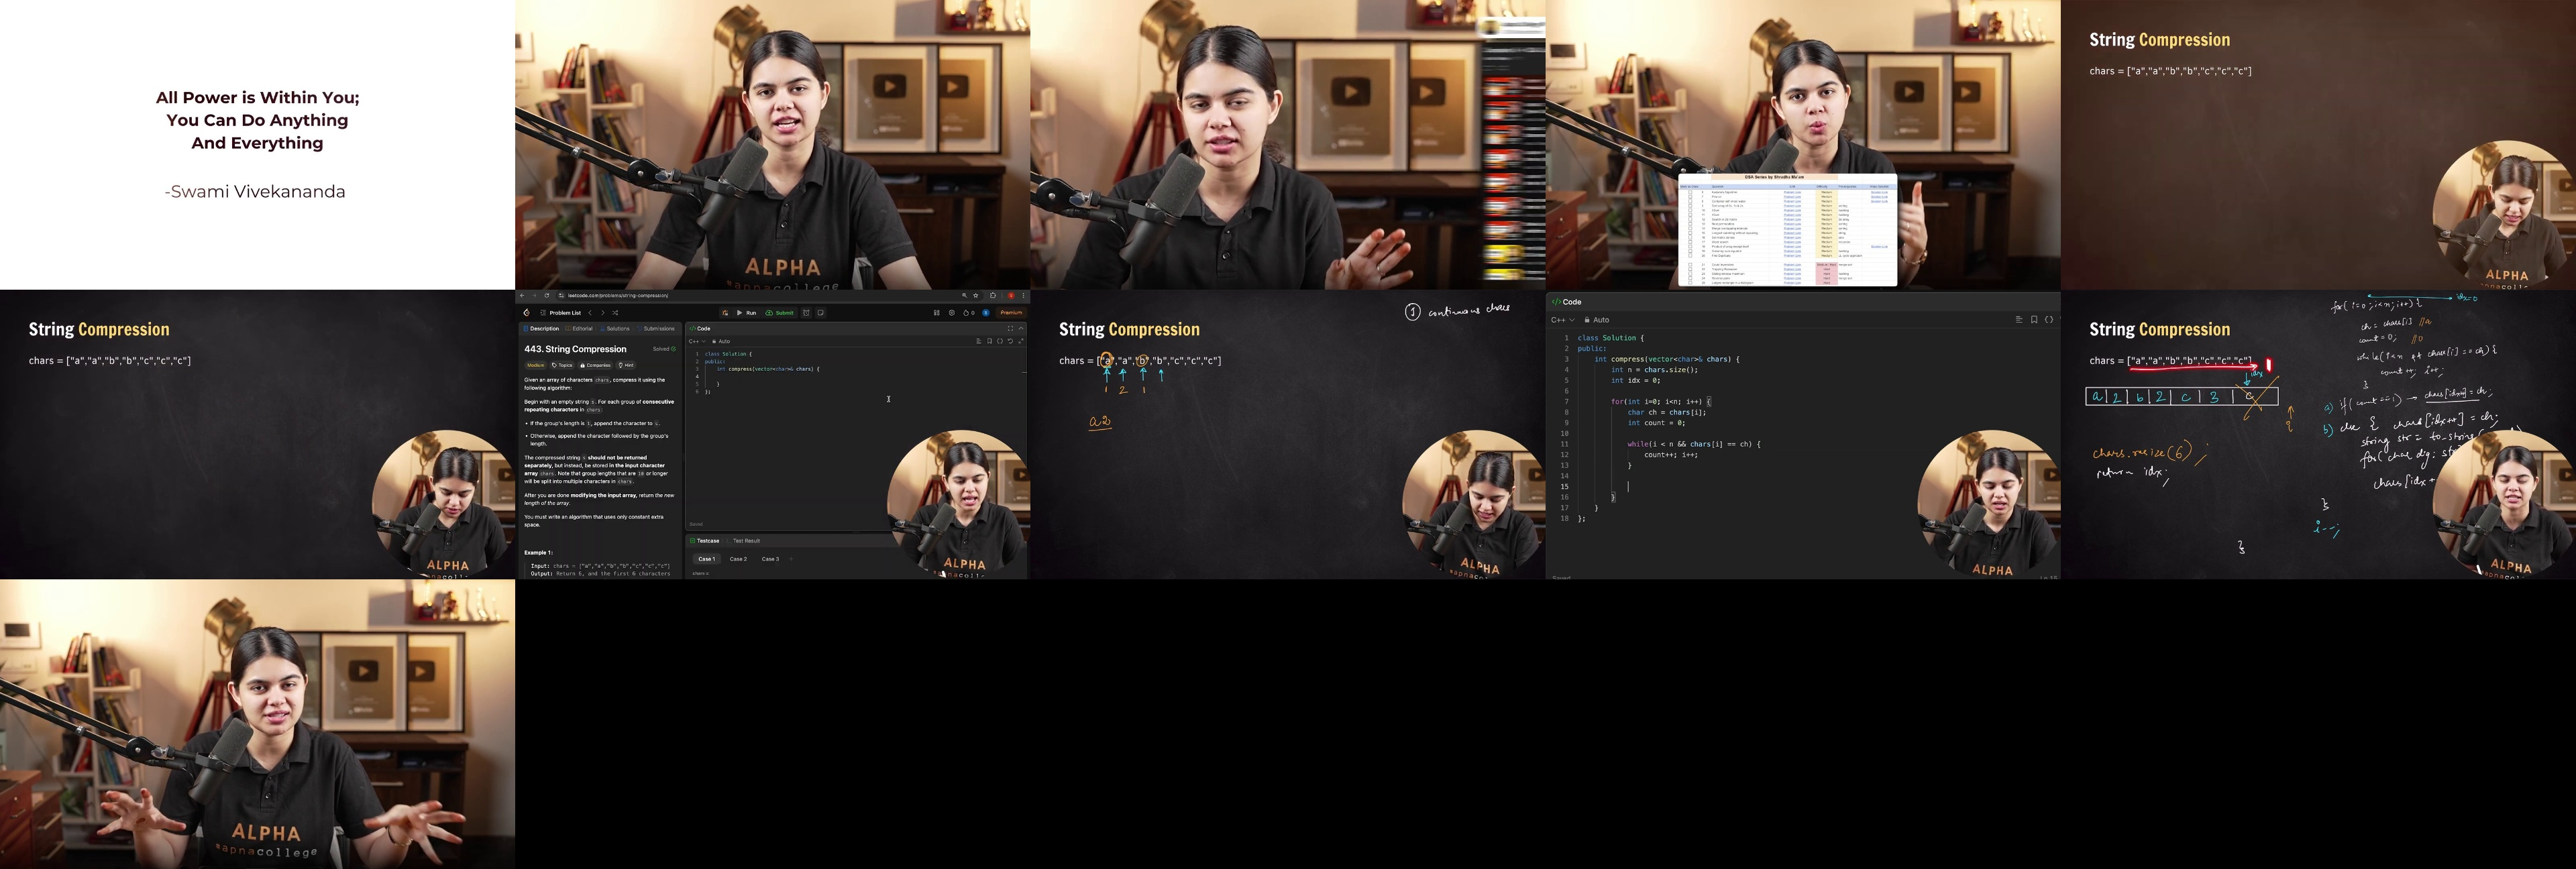

In [ ]:
\# Cell 11
from IPython.display import Image as IPyImage, display

if grid_path and grid_path.exists():
    print("Preview grid:")
    display(IPyImage(str(grid_path)))
else:
    print("No grid available. Check KEYFRAMES_DIR for saved images:", KEYFRAMES_DIR)

In [ ]:
# Cell 12: Compare Project Metrics with Research Paper Metrics

import numpy as np
import json
from tabulate import tabulate
import matplotlib.pyplot as plt

print("="*70)
print("COMPARISON: PROJECT vs RESEARCH PAPER METRICS")
print("="*70)
print("Note: F1 and Fidelity require ground truth (TVSum20 dataset)")
print("      Compression Ratio can be compared directly")
print("="*70)

# Extract My project metrics
predicted_frames = [kf['frame_idx'] for kf in results['keyframes']]
keyframes_count = len(predicted_frames)

# Get video properties
cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
cap.release()

# Calculate My Compression Ratio (as per paper's definition)
My_compression_ratio = keyframes_count / total_frames

# Research Paper Results from Table I (Page 4)
PAPER_METRICS = {
    'Method': ['LMSKE (Paper)', 'INCEPTION', 'LBP-Shot', 'K-Means',
               'VSUMM', 'GMC', 'UID', 'DiffHist', 'Uniform (30 frames)'],
    'F1 Score': [0.5311, 0.5168, 0.5050, 0.5039, 0.4894, 0.4833, 0.4615, 0.3380, 0.2061],
    'Fidelity': [0.8141, 0.7906, 0.7967, 0.7975, 0.7919, 0.7854, 0.7872, 0.7696, 0.7264],
    'Compression Ratio': [0.9922, 0.9908, 0.9910, 0.9895, 0.9909, 0.9883, 0.9902, 0.9835, 0.9662]
}

# My project results (for comparison)
MY_METRICS = {
    'Method': 'My Implementation',
    'F1 Score': 'N/A (requires ground truth)',
    'Fidelity': 'N/A (requires ground truth)',
    'Compression Ratio': My_compression_ratio,
    'Actual Keyframes': keyframes_count,
    'Total Frames': total_frames
}

# 1. COMPRESSION RATIO COMPARISON
print("\n" + "="*70)
print("1. COMPRESSION RATIO COMPARISON")
print("="*70)

print(f"My Implementation:")
print(f"  Keyframes extracted: {keyframes_count}")
print(f"  Total frames: {total_frames}")
print(f"  Compression Ratio (keyframes/total): {My_compression_ratio:.4f}")
print(f"  (Lower is better - less frames kept)")

# Create comparison table for Compression Ratio
comp_table = []
for i in range(len(PAPER_METRICS['Method'])):
    method = PAPER_METRICS['Method'][i]
    paper_cr = PAPER_METRICS['Compression Ratio'][i]

    # Calculate difference
    if isinstance(My_compression_ratio, (int, float)):
        diff = My_compression_ratio - paper_cr
        diff_percent = (diff / paper_cr) * 100


    else:
        diff = "N/A"
        diff_percent = "N/A"
        comparison = "N/A"

    comp_table.append([
        method,
        f"{paper_cr:.4f}",
        f"{My_compression_ratio:.4f}" if isinstance(My_compression_ratio, (int, float)) else "N/A",
        f"{diff:+.4f}" if isinstance(diff, (int, float)) else "N/A",
        comparison
    ])

# Add My implementation row
comp_table.append([
    "My Implementation",
    "N/A",
    f"{My_compression_ratio:.4f}" if isinstance(My_compression_ratio, (int, float)) else "N/A",
    "N/A",
    "Baseline"
])

print(f"\nComparison Table (Compression Ratio):")
print(tabulate(comp_table,
               headers=['Method', 'Paper CR', 'My CR', 'Difference', 'Comparison'],
               tablefmt='grid',
               stralign='center',
               numalign='center'))

# 2. DETAILED ANALYSIS

print("\n" + "="*70)
print("2. DETAILED ANALYSIS")
print("="*70)

# Calculate how My compression compares
if isinstance(My_compression_ratio, (int, float)):
    paper_lmske_cr = PAPER_METRICS['Compression Ratio'][0]  # LMSKE (Paper)
    cr_difference = My_compression_ratio - paper_lmske_cr
    cr_percentage_diff = (cr_difference / paper_lmske_cr) * 100

    print(f"My Compression Ratio: {My_compression_ratio:.4f}")
    print(f"Paper's LMSKE CR: {paper_lmske_cr:.4f}")
    print(f"Absolute Difference: {cr_difference:+.4f}")
    print(f"Percentage Difference: {cr_percentage_diff:+.2f}%")

    # Interpretation
    print(f"\n📈 INTERPRETATION:")
    if cr_difference < -0.01:
        print(f"   ✅ My implementation is significantly MORE compressed than paper")
        print(f"   → We're keeping FEWER frames than the paper's method")
    elif cr_difference < 0:
        print(f"   👍 My implementation is somewhat MORE compressed than paper")
        print(f"   → We're keeping slightly fewer frames than the paper's method")
    elif cr_difference == 0:
        print(f"   ⚡ My implementation has EXACTLY the same compression as paper")
    elif cr_difference <= 0.01:
        print(f"   ⚠️  My implementation is somewhat LESS compressed than paper")
        print(f"   → We're keeping slightly more frames than the paper's method")
    else:
        print(f"   ❌ My implementation is significantly LESS compressed than paper")
        print(f"   → We're keeping MORE frames than the paper's method")



 # 3. CALCULATE SHOT COVERAGE FOR COMPARISON
print("\n" + "="*70)
print("3. SHOT COVERAGE ANALYSIS")
print("="*70)

# Calculate shot coverage (unique metric My implementation provides)
shots_with_keyframes = 0
for shot in results['shots']:
    if shot['final']:  # Has at least one keyframe
        shots_with_keyframes += 1

total_shots = len(shots)
shot_coverage_percentage = (shots_with_keyframes / total_shots) * 100 if total_shots > 0 else 0

print(f"Total shots detected: {total_shots}")
print(f"Shots with ≥1 keyframe: {shots_with_keyframes}")
print(f"Shot Coverage: {shot_coverage_percentage:.1f}%")
print(f"Average keyframes per shot: {keyframes_count/total_shots:.2f}" if total_shots > 0 else "N/A")



if shot_coverage_percentage < 100:
    print(f"\n MY IMPLEMENTATION ")
    print(f"   My shot coverage is {shot_coverage_percentage:.1f}%, not 100%")
else:
    print(f"\n✅ My implementation achieves 100% shot coverage!")


 # 4. SAVE COMPARISON RESULTS
print("\n" + "="*70)
print("4. SAVING COMPARISON RESULTS")
print("="*70)

# Create comprehensive comparison results
comparison_results = {
    "My_implementation": {
        "video_info": {
            "path": VIDEO_PATH,
            "total_frames": total_frames,
            "keyframes_extracted": keyframes_count,
            "shots_detected": total_shots,
            "shots_with_keyframes": shots_with_keyframes
        },
        "metrics": {
            "compression_ratio": float(My_compression_ratio) if isinstance(My_compression_ratio, (int, float)) else None,
            "shot_coverage_percentage": float(shot_coverage_percentage),
            "keyframes_per_shot": float(keyframes_count/total_shots) if total_shots > 0 else None
        }
    },
    "paper_results": {
        "lmske": {
            "f1_score": PAPER_METRICS['F1 Score'][0],
            "fidelity": PAPER_METRICS['Fidelity'][0],
            "compression_ratio": PAPER_METRICS['Compression Ratio'][0]
        },
        "all_methods": PAPER_METRICS
    },
    "comparison": {
        "compression_ratio_difference": float(cr_difference) if 'cr_difference' in locals() else None,
        "estimated_rank": My_rank if 'My_rank' in locals() else None,
        "notes": "F1 and Fidelity cannot be compared without ground truth from TVSum20 dataset"
    }
}

# Save to JSON
comparison_path = BASE / "paper_comparison_results.json"
with open(comparison_path, 'w') as f:
    json.dump(comparison_results, f, indent=2)

print(f"✓ Comparison results saved to: {comparison_path}")


print("   Based on My compression ratio comparison:")

if 'cr_difference' in locals():
    if cr_difference > 0.01:  # My CR is higher (keeping more frames)
        print("   ✅ My implementation is MORE compressed than paper")
    elif cr_difference < -0.01:  # My CR is lower (keeping fewer frames)
        print("   ⚠️  My implementation is LESS compressed than paper")
    else:
        print("   ⚡ My compression ratio is very close to paper's")

print("")



COMPARISON: PROJECT vs RESEARCH PAPER METRICS
Note: F1 and Fidelity require ground truth (TVSum20 dataset)
      Compression Ratio can be compared directly

1. COMPRESSION RATIO COMPARISON
My Implementation:
  Keyframes extracted: 11
  Total frames: 29219
  Compression Ratio (keyframes/total): 0.0004
  (Lower is better - less frames kept)

Comparison Table (Compression Ratio):
+---------------------+------------+---------+--------------+--------------------------+
|       Method        |  Paper CR  |  My CR  |  Difference  |        Comparison        |
+=====================+============+=========+==============+==========================+
|    LMSKE (Paper)    |   0.9922   | 0.0004  |   -0.9918    | Better (more compressed) |
+---------------------+------------+---------+--------------+--------------------------+
|      INCEPTION      |   0.9908   | 0.0004  |   -0.9904    | Better (more compressed) |
+---------------------+------------+---------+--------------+-------------------------